In [1]:
# 1. Import de bibliotecas

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
MAX_ITER = 1000

In [2]:
# 2. Carregar Dataset limpo e separar
df = pd.read_csv('./data/Titanic-Dataset-Clean.csv')
X = df.drop(columns=['Survived'])
y = df['Survived']

print(X.head())
print('-----------------------')
print(y.head())

   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833
2       3    1  26.0      0      0   7.9250
3       1    1  35.0      1      0  53.1000
4       3    0  35.0      0      0   8.0500
-----------------------
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


A procurar os melhores parâmetros para a Rede Neuronal...

Melhores parâmetros encontrados: {'mlp__activation': 'tanh', 'mlp__hidden_layer_sizes': (100,)}
Accuracy esperada (Validação Cruzada): 0.8202

RELATÓRIO MLP
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       105
           1       0.81      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



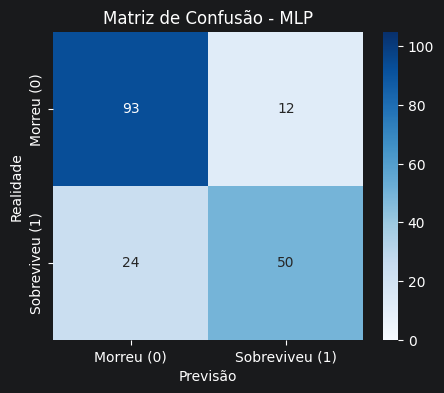

In [3]:
# 3. MultiLayer Perceptron
from sklearn.neural_network import MLPClassifier

# Pipeline: Garante que o escalonamento é feito corretamente em cada teste
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=MAX_ITER, random_state=RANDOM_STATE))
])

# Grelha de Hiperparâmetros
# Vamos testar apenas a arquitetura das camadas e a função de ativação
param_grid = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "mlp__activation": ["relu", "tanh"]
}

# Configurar o GridSearch
grid = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=param_grid,
    cv=5,  # 5 rondas de validação cruzada
    n_jobs=-1  # Usa todos os núcleos do processador para ser rápido
)

# Procurar a melhor combinação
print("A procurar os melhores parâmetros para a Rede Neuronal...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
grid.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid.best_params_}")
print(f"Accuracy esperada (Validação Cruzada): {grid.best_score_:.4f}")

# Avaliar o modelo vencedor nos dados de teste reais
best_mlp = grid.best_estimator_
previsoes = best_mlp.predict(X_test)

print("\n" + "=" * 40)
print("RELATÓRIO MLP")
print("=" * 40)
print(classification_report(y_test, previsoes))

# Matriz de Confusão
matriz = confusion_matrix(y_test, previsoes)
plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            vmin=-0, vmax=105,
            xticklabels=['Morreu (0)', 'Sobreviveu (1)'],
            yticklabels=['Morreu (0)', 'Sobreviveu (1)'])
plt.title('Matriz de Confusão - MLP')
plt.ylabel('Realidade')
plt.xlabel('Previsão')
plt.show()

A procurar os melhores parâmetros para a Random Forest...

Melhores parâmetros encontrados: {'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Accuracy esperada (Validação Cruzada): 0.8272

RELATÓRIO RANDOM FOREST
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.72      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



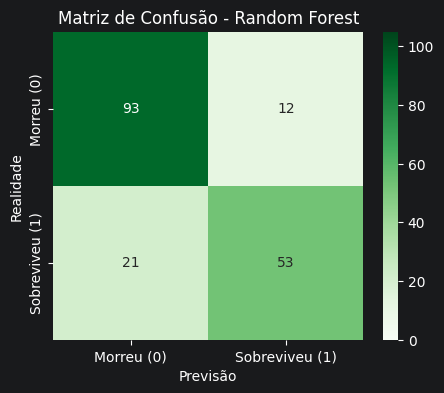

In [4]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Pipeline
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE))
])

# Grelha de Hiperparâmetros
param_grid_rf = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 5, 10],
    "rf__min_samples_split": [2, 5]
}

# Configurar o GridSearch
grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    n_jobs=-1
)

# Procurar a melhor combinação
print("A procurar os melhores parâmetros para a Random Forest...")
grid_rf.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_rf.best_params_}")
print(f"Accuracy esperada (Validação Cruzada): {grid_rf.best_score_:.4f}")

# Avaliar o modelo vencedor nos dados de teste reais
best_rf = grid_rf.best_estimator_
previsoes_rf = best_rf.predict(X_test)

print("\n" + "=" * 40)
print("RELATÓRIO RANDOM FOREST")
print("=" * 40)
print(classification_report(y_test, previsoes_rf))

# Matriz de Confusão
matriz_rf = confusion_matrix(y_test, previsoes_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens',
            vmin=-0, vmax=105,
            xticklabels=['Morreu (0)', 'Sobreviveu (1)'],
            yticklabels=['Morreu (0)', 'Sobreviveu (1)'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Realidade')
plt.xlabel('Previsão')
plt.show()

A procurar os melhores parâmetros para a Regressão Logística...

Melhores parâmetros encontrados: {'lr__C': 0.1, 'lr__solver': 'lbfgs'}
Accuracy esperada (Validação Cruzada): 0.8005

RELATÓRIO REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       105
           1       0.78      0.70      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



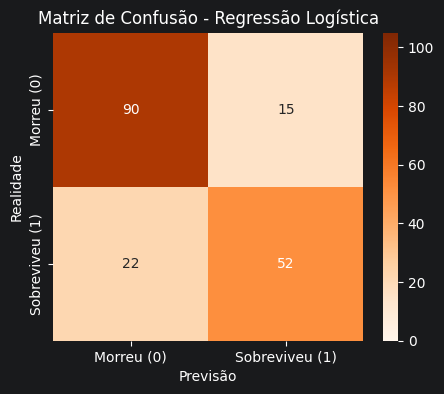

In [5]:
#
from sklearn.linear_model import LogisticRegression

# Pipeline
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE))
])

# Grelha de Hiperparâmetros
param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__solver": ["lbfgs", "liblinear"]
}

# Configurar o GridSearch
grid_lr = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid_lr,
    cv=5,
    n_jobs=-1
)

# Procurar a melhor combinação
print("A procurar os melhores parâmetros para a Regressão Logística...")
grid_lr.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_lr.best_params_}")
print(f"Accuracy esperada (Validação Cruzada): {grid_lr.best_score_:.4f}")

# Avaliar o modelo vencedor nos dados de teste reais
best_lr = grid_lr.best_estimator_
previsoes_lr = best_lr.predict(X_test)

print("\n" + "=" * 40)
print("RELATÓRIO REGRESSÃO LOGÍSTICA")
print("=" * 40)
print(classification_report(y_test, previsoes_lr))

# Matriz de Confusão
matriz_lr = confusion_matrix(y_test, previsoes_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(matriz_lr, annot=True, fmt='d', cmap='Oranges',
            vmin=-0, vmax=105,
            xticklabels=['Morreu (0)', 'Sobreviveu (1)'],
            yticklabels=['Morreu (0)', 'Sobreviveu (1)'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Realidade')
plt.xlabel('Previsão')
plt.show()